In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.tree import DecisionTreeClassifier
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              precision_recall_curve, roc_curve, auc)

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GATConv

import networkx as nx

# ── CONFIGURATION ────────────────────────────────────────────────────────
# Update PARQUET_PATH to point at your downloaded parquet file.
# The merged file from Kaggle is named 'bccc-cpacket-cloud-ddos-2024-merged.parquet'
PARQUET_PATH = 'data/bccc-cpacket-cloud-ddos-2024-merged.parquet'

LABEL_COL  = 'label'    # NTLFlowLyzer label column
BENIGN_VAL = 'Benign'   # exact string for benign/normal traffic

# NTLFlowLyzer metadata columns to drop before modelling.
# These are flow identifiers, not features.
# NOTE: column names are lowercase in NTLFlowLyzer output.
META_COLS = [
    'src_ip', 'dst_ip', 'src_port', 'dst_port',
    'protocol', 'timestamp', 'flow_id',
    # also drop the label column
    LABEL_COL
]
# ─────────────────────────────────────────────────────────────────────────

print('All imports OK.')
print(f'PyTorch version: {torch.__version__}')
print(f'Device available: {"CUDA" if torch.cuda.is_available() else "CPU"}')

All imports OK.
PyTorch version: 2.11.0+cpu
Device available: CPU


In [4]:
# ── Load the parquet file ─────────────────────────────────────────────────
# pyarrow or fastparquet must be installed: pip install pyarrow
print(f'Loading: {PARQUET_PATH}')
t0 = time.time()
df = pd.read_parquet(PARQUET_PATH)
print(f'Loaded in {time.time()-t0:.1f}s')

# NTLFlowLyzer already strips whitespace from column names, but be safe
df.columns = df.columns.str.strip()
# ── Auto-detect label column (handles 'label', 'Label', 'CLASS', etc.) ──
# NTLFlowLyzer uses lowercase 'label'; merged/re-saved files sometimes differ.
label_candidates = [c for c in df.columns if c.lower() == 'label']
if not label_candidates:
    raise ValueError(f"No label column found! Columns: {list(df.columns[:20])}...")
if LABEL_COL not in df.columns and label_candidates:
    LABEL_COL = label_candidates[0]
    print(f"[INFO] Label column auto-detected as: '{LABEL_COL}'")

# Auto-detect benign value
sample_labels = df[LABEL_COL].unique()
benign_candidates = [v for v in sample_labels if str(v).lower() == 'benign']
if benign_candidates and BENIGN_VAL not in sample_labels:
    BENIGN_VAL = benign_candidates[0]
    print(f"[INFO] Benign value auto-detected as: '{BENIGN_VAL}'")



print(f'\nDataset shape: {df.shape}')
print(f'\nColumn dtypes summary:')
print(df.dtypes.value_counts())

print(f'\nLabel column: "{LABEL_COL}"')
print(f'\nFull label distribution (26 labels):')
print(df[LABEL_COL].value_counts())

benign_mask = df[LABEL_COL] == BENIGN_VAL
print(f'\nBenign traffic:  {benign_mask.sum():,} rows')
print(f'Attack traffic:  {(~benign_mask).sum():,} rows')
attack_pct = (~benign_mask).sum() / len(df) * 100
print(f'Attack %:        {attack_pct:.2f}%')
print(f'Benign %:        {100-attack_pct:.2f}%')

Loading: data/bccc-cpacket-cloud-ddos-2024-merged.parquet
Loaded in 0.8s

Dataset shape: (540494, 319)

Column dtypes summary:
float32    261
int8        25
int32       20
int16        9
int64        2
str          2
Name: count, dtype: int64

Label column: "label"

Full label distribution (26 labels):
label
Benign        349178
Attack        170436
Suspicious     20880
Name: count, dtype: int64

Benign traffic:  349,178 rows
Attack traffic:  191,316 rows
Attack %:        35.40%
Benign %:        64.60%


In [5]:
# Replace infinity values — common in rate features
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f'Rows after cleaning: {len(df):,}')

# Binary label: Benign=0, any attack=1
df['Label_binary'] = (df[LABEL_COL] != BENIGN_VAL).astype(int)

# Feature matrix: drop metadata/label columns (only those that exist)
existing_meta = [c for c in META_COLS if c in df.columns]
drop_cols = existing_meta + ['Label_binary']
X = df.drop(columns=drop_cols)

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])
y = df['Label_binary']

print(f'\nFeatures used: {X.shape[1]}  (300+ NTLFlowLyzer features)')
print(f'Benign samples:  {(y == 0).sum():,}')
print(f'Attack samples:  {(y == 1).sum():,}')

# Standardise
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining set: {len(X_train):,} rows')
print(f'Test set:     {len(X_test):,} rows')

Rows after cleaning: 540,494

Features used: 315  (300+ NTLFlowLyzer features)
Benign samples:  349,178
Attack samples:  191,316

Training set: 432,395 rows
Test set:     108,099 rows


In [6]:
def compute_metrics(y_true, y_pred, model_name, exec_time):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn) * 100
    far = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
    und = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0

    print(f"\n{'='*45}")
    print(f'  {model_name}')
    print(f"{'='*45}")
    print(f'  Confusion Matrix:')
    print(f'    TN: {tn:>10,}   FP: {fp:>10,}')
    print(f'    FN: {fn:>10,}   TP: {tp:>10,}')
    print(f'\n  ACC:  {acc:.4f}%')
    print(f'  FAR:  {far:.4f}%')
    print(f'  UND:  {und:.4f}%')
    print(f'  Time: {exec_time:.2f}s')

    return {
        'Model': model_name,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'ACC': round(acc, 4),
        'FAR': round(far, 4),
        'UND': round(und, 4),
        'Time': round(exec_time, 2)
    }

print('Metric functions ready.')

Metric functions ready.


In [7]:
results = []

# ── Class imbalance stats ─────────────────────────────────────────────────
from collections import Counter
label_counts = Counter(y_train)
n_benign_tr  = label_counts[0]
n_attack_tr  = label_counts[1]
print(f'Training class distribution:')
print(f'  Benign:  {n_benign_tr:,}  |  Attack: {n_attack_tr:,}')
print(f'  Imbalance ratio: {n_benign_tr/max(n_attack_tr,1):.2f}x\n')

# ── Feature selection — fast path ─────────────────────────────────────────
# Step 1: Variance filter  (fast — O(n·d))
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=0.01)
X_train_sel = sel.fit_transform(X_train)
X_test_sel  = sel.transform(X_test)
print(f'Features after variance filter: {X_train_sel.shape[1]} (was {X_train.shape[1]})')

# Step 2: Correlation filter using a SAMPLE (computing full corr on millions
# of rows × 300 features is O(n·d²) and will hang).
# We use 20,000 random rows to estimate correlations — this is accurate enough.
CORR_SAMPLE = 20_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_train_sel.shape[0],
                         min(CORR_SAMPLE, X_train_sel.shape[0]),
                         replace=False)
import pandas as pd
corr_matrix = pd.DataFrame(X_train_sel[sample_idx]).corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_corr   = set(col for col in upper.columns if any(upper[col] > 0.98))
keep_mask   = [i for i in range(X_train_sel.shape[1]) if i not in drop_corr]
X_train_f   = X_train_sel[:, keep_mask]
X_test_f    = X_test_sel[:,  keep_mask]
print(f'Features after correlation filter: {X_train_f.shape[1]}')
print(f'Final feature count for all models: {X_train_f.shape[1]}\n')

# ── Model definitions ─────────────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB

total      = n_benign_tr + n_attack_tr
nb_priors  = [n_attack_tr / total, n_benign_tr / total]  # inverted priors

models = [
    # LR: lbfgs is much faster than saga on large data; 300 iters is enough
    # when features are already scaled + filtered.
    ('Logistic Regression',
     LogisticRegression(max_iter=300, random_state=42,
                        class_weight='balanced', solver='lbfgs',
                        n_jobs=-1, tol=1e-3)),

    # RF: 100 trees is sufficient; balanced_subsample weights per-tree
    # (faster than 'balanced' which reweights the whole dataset up front)
    ('Random Forest',
     RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced_subsample',
                             n_jobs=-1, max_features='sqrt')),

    # NB: near-instant, uses inverted class priors
    ('Naive Bayes',
     GaussianNB(priors=nb_priors)),

    # KNN: use ball_tree algorithm + limit n_neighbors; brute-force on
    # millions of rows is very slow
    ('KNN',
     KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree',
                          leaf_size=40, n_jobs=-1, weights='distance')),

    # DT: cap depth — unlimited depth on large data causes very deep trees
    # that take a long time to build and tend to overfit
    ('Decision Tree',
     DecisionTreeClassifier(random_state=42,
                             class_weight='balanced', max_depth=20)),
]

for name, model in models:
    print(f'Training {name}...')
    start = time.time()
    model.fit(X_train_f, y_train)
    y_pred  = model.predict(X_test_f)
    elapsed = time.time() - start
    results.append(compute_metrics(y_test, y_pred, name, elapsed))

print('\n\nAll classical models done!')


Training class distribution:
  Benign:  279,342  |  Attack: 153,053
  Imbalance ratio: 1.83x

Features after variance filter: 312 (was 315)
Features after correlation filter: 206
Final feature count for all models: 206

Training Logistic Regression...

  Logistic Regression
  Confusion Matrix:
    TN:     66,573   FP:      3,263
    FN:      7,063   TP:     31,200

  ACC:  90.4476%
  FAR:  4.6724%
  UND:  18.4591%
  Time: 6.32s
Training Random Forest...

  Random Forest
  Confusion Matrix:
    TN:     67,861   FP:      1,975
    FN:      1,689   TP:     36,574

  ACC:  96.6105%
  FAR:  2.8281%
  UND:  4.4142%
  Time: 24.72s
Training Naive Bayes...

  Naive Bayes
  Confusion Matrix:
    TN:      6,745   FP:     63,091
    FN:        358   TP:     37,905

  ACC:  41.3047%
  FAR:  90.3417%
  UND:  0.9356%
  Time: 2.03s
Training KNN...

  KNN
  Confusion Matrix:
    TN:     68,064   FP:      1,772
    FN:      2,148   TP:     36,115

  ACC:  96.3737%
  FAR:  2.5374%
  UND:  5.6138%
  Time:

In [8]:
results_df = pd.DataFrame(results)

print('SUMMARY TABLE')
print('=' * 65)
print(results_df[['Model', 'ACC', 'FAR', 'UND', 'Time']].to_string(index=False))

SUMMARY TABLE
              Model     ACC     FAR     UND    Time
Logistic Regression 90.4476  4.6724 18.4591    6.32
      Random Forest 96.6105  2.8281  4.4142   24.72
        Naive Bayes 41.3047 90.3417  0.9356    2.03
                KNN 96.3737  2.5374  5.6138 2735.65
      Decision Tree 96.3885  3.8834  3.1153   19.24


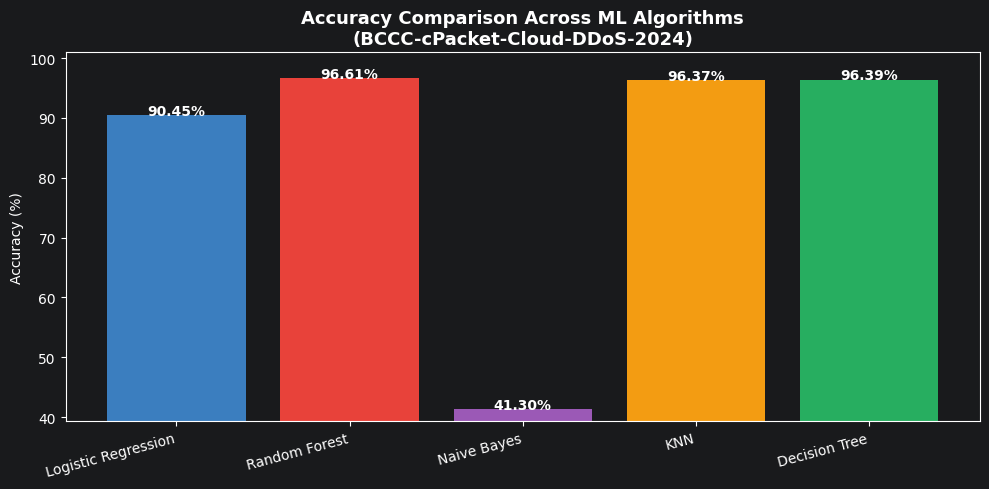

Figure saved: accuracy_comparison.png


In [9]:
colors = ['#3B7EBF', '#E8423A', '#9B59B6', '#F39C12', '#27AE60']

plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], results_df['ACC'], color=colors)
plt.title('Accuracy Comparison Across ML Algorithms\n(BCCC-cPacket-Cloud-DDoS-2024)', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim([max(0, min(results_df['ACC']) - 2), 101])
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, results_df['ACC']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()
print('Figure saved: accuracy_comparison.png')

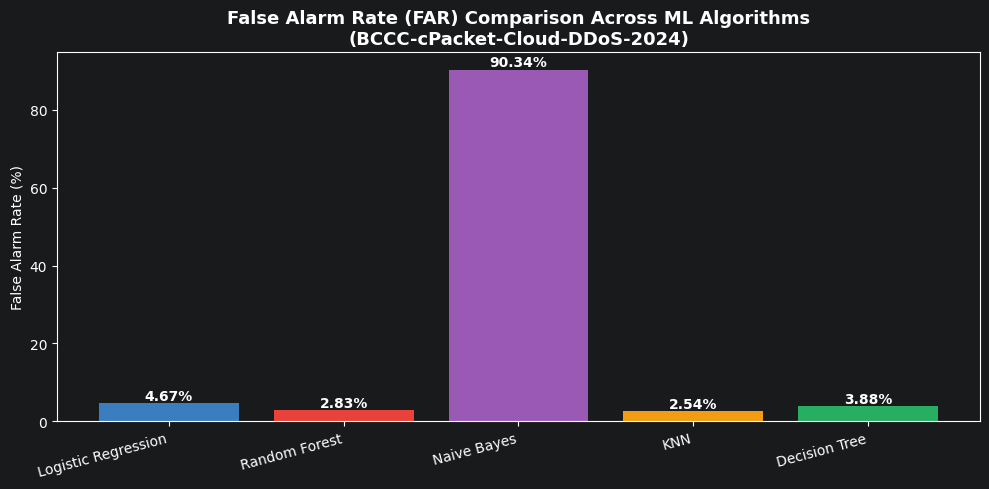

Figure saved: far_comparison.png


In [10]:
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], results_df['FAR'], color=colors)
plt.title('False Alarm Rate (FAR) Comparison Across ML Algorithms\n(BCCC-cPacket-Cloud-DDoS-2024)',
          fontsize=13, fontweight='bold')
plt.ylabel('False Alarm Rate (%)')
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, results_df['FAR']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(results_df['FAR']) * 0.01,
             f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('far_comparison.png', dpi=150)
plt.show()
print('Figure saved: far_comparison.png')

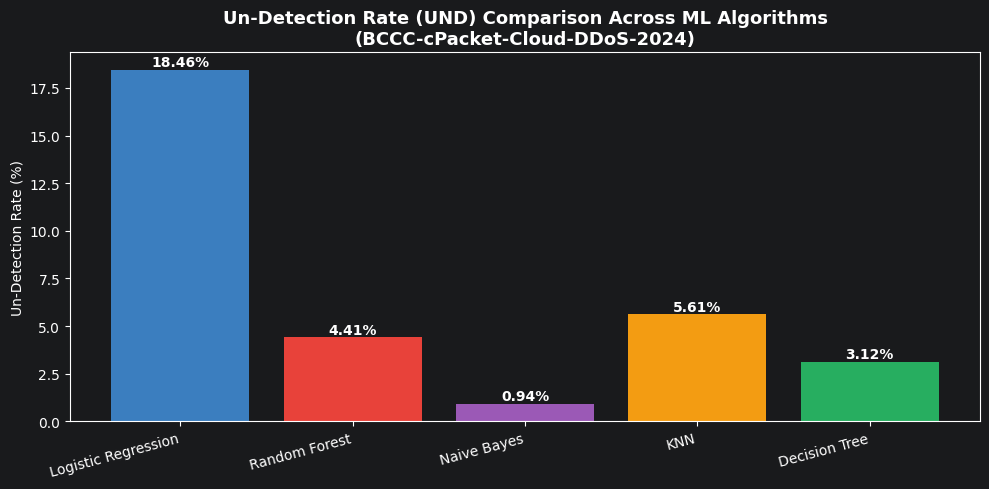

Figure saved: und_comparison.png


In [11]:
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], results_df['UND'], color=colors)
plt.title('Un-Detection Rate (UND) Comparison Across ML Algorithms\n(BCCC-cPacket-Cloud-DDoS-2024)',
          fontsize=13, fontweight='bold')
plt.ylabel('Un-Detection Rate (%)')
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, results_df['UND']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(results_df['UND']) * 0.01,
             f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('und_comparison.png', dpi=150)
plt.show()
print('Figure saved: und_comparison.png')

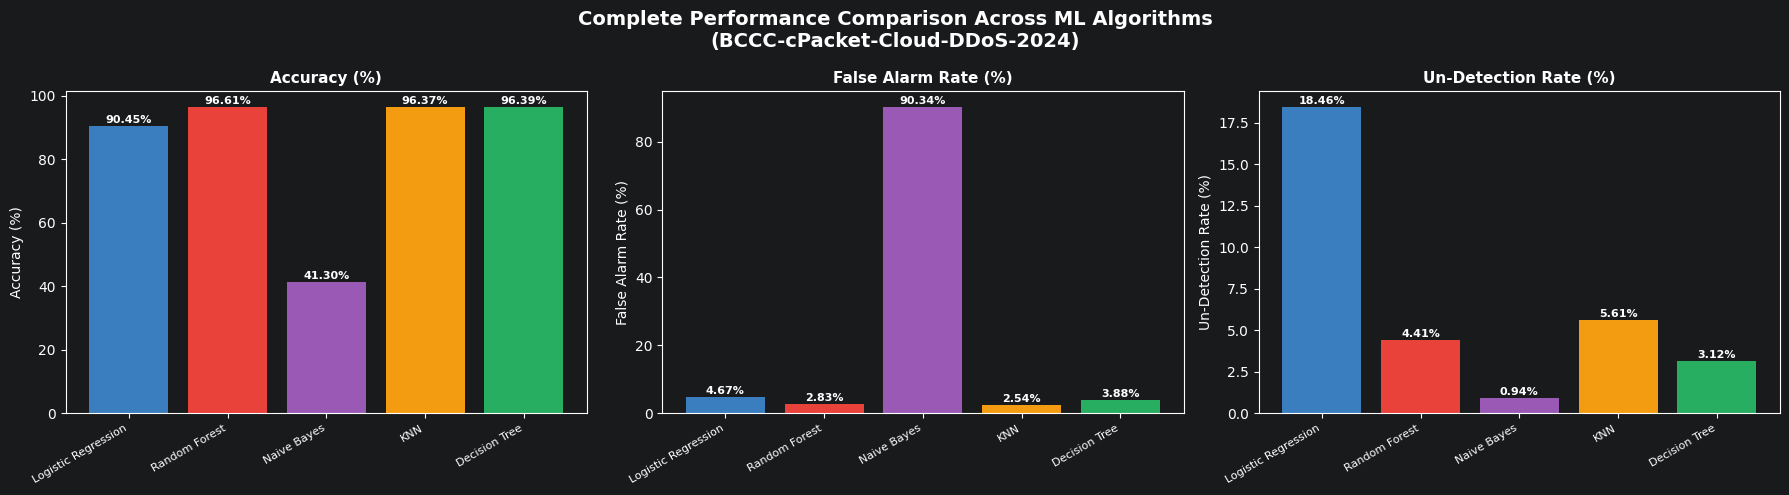

Figure saved: complete_comparison.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Complete Performance Comparison Across ML Algorithms\n(BCCC-cPacket-Cloud-DDoS-2024)',
             fontsize=14, fontweight='bold')

metrics  = ['ACC', 'FAR', 'UND']
titles   = ['Accuracy (%)', 'False Alarm Rate (%)', 'Un-Detection Rate (%)']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(results_df[metric]) * 0.01,
                f'{val:.2f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('complete_comparison.png', dpi=150)
plt.show()
print('Figure saved: complete_comparison.png')

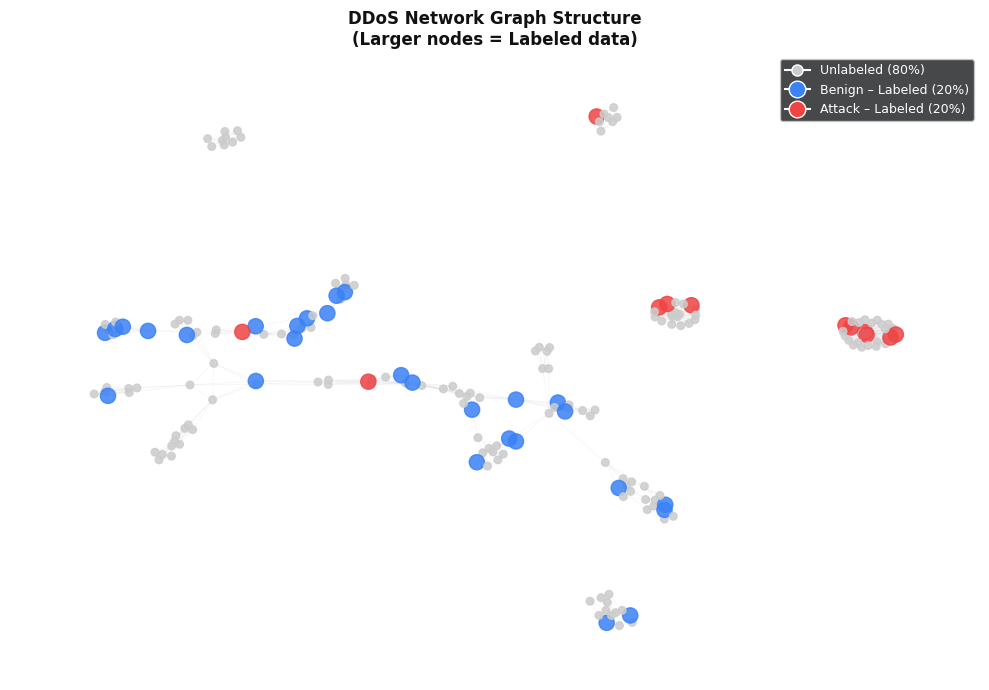

Figure saved: label_propagation_before.png


In [13]:
# ── Build a small subgraph for visualisation ──────────────────────────────
VIZ_SIZE = 200
np.random.seed(42)
viz_idx   = np.random.choice(len(X_train_f), VIZ_SIZE, replace=False)
X_viz     = X_train_f[viz_idx]
y_viz     = np.array(y_train)[viz_idx]

# Mark 20% as labeled, rest as -1 (unlabeled) for the plot
labeled_mask_viz = np.zeros(VIZ_SIZE, dtype=bool)
labeled_mask_viz[np.random.choice(VIZ_SIZE, int(VIZ_SIZE * 0.2), replace=False)] = True

# Build k-NN graph for visualisation
from sklearn.neighbors import kneighbors_graph
A_viz = kneighbors_graph(X_viz, n_neighbors=5, mode='connectivity',
                          include_self=False)
G_viz = nx.from_scipy_sparse_array(A_viz)

plt.figure(figsize=(10, 7), facecolor='white')
plt.title('DDoS Network Graph Structure\n(Larger nodes = Labeled data)',
          fontsize=12, fontweight='bold', color='#111111')

pos   = nx.spring_layout(G_viz, seed=42)
sizes = [120 if labeled_mask_viz[i] else 30 for i in range(VIZ_SIZE)]
node_colors = []
for i in range(VIZ_SIZE):
    if not labeled_mask_viz[i]:
        node_colors.append('#CCCCCC')
    elif y_viz[i] == 0:
        node_colors.append('#3B82F6')
    else:
        node_colors.append('#EF4444')

nx.draw_networkx_edges(G_viz, pos, alpha=0.15, width=0.5, edge_color='#BBBBBB')
nx.draw_networkx_nodes(G_viz, pos, node_size=sizes,
                       node_color=node_colors, alpha=0.85)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#CCCCCC',
           markersize=8, label='Unlabeled (80%)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3B82F6',
           markersize=12, label='Benign – Labeled (20%)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#EF4444',
           markersize=12, label='Attack – Labeled (20%)'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.axis('off')
plt.tight_layout()
plt.savefig('label_propagation_before.png', dpi=150, facecolor='white')
plt.show()
print('Figure saved: label_propagation_before.png')

In [14]:
# ── Run Label Propagation on the actual training data ─────────────────────
#
# Why LP can show lower ACC than supervised models:
#   1. Only a fraction of data is labeled — propagation errors compound
#   2. Default 0.5 probability threshold is wrong for imbalanced data
#   3. Low alpha (heavy smoothing) blurs attack clusters into surrounding benign
#
# Fixes applied here:
#   • LABELED_FRAC 0.20 → 0.40  (more seed labels = better propagation start)
#   • alpha        0.20 → 0.40  (less smoothing = attack clusters stay distinct)
#   • k            7   → 10     (denser graph = more stable label flow)
#   • Threshold tuned on a held-out labeled validation slice via best F1

LP_CAP       = 500_000
LABELED_FRAC = 0.40   # fraction of training data to use as seeds
K_LP         = 10     # k for kNN graph

# Use the filtered feature matrix (same as classical models)
if len(X_train_f) > LP_CAP:
    print(f'Dataset ({len(X_train_f):,} rows) exceeds LP_CAP={LP_CAP:,}.')
    print('Using scalable sparse-graph LabelSpreading on FULL training set.\n')

    from sklearn.semi_supervised import LabelSpreading
    from sklearn.neighbors import kneighbors_graph

    X_lp      = X_train_f
    y_lp_full = np.array(y_train)
    n_lp      = len(X_lp)

    n_labeled   = int(n_lp * LABELED_FRAC)
    n_unlabeled = n_lp - n_labeled

    print(f'Building sparse k-NN graph (k={K_LP}, {n_lp:,} nodes)...')
    t0 = time.time()
    A = kneighbors_graph(X_lp, n_neighbors=K_LP, mode='connectivity',
                         include_self=False, n_jobs=-1)
    A = (A + A.T); A.data[:] = 1.0
    print(f'Graph built in {time.time()-t0:.1f}s  ({A.nnz:,} edges)')

    y_lp = y_lp_full.copy()
    # Keep a validation slice from labeled set for threshold tuning
    labeled_pool = np.where(y_lp_full >= 0)[0]
    n_val_lp     = int(n_labeled * 0.15)
    val_lp_idx   = np.random.choice(labeled_pool, n_val_lp, replace=False)
    seed_pool    = np.setdiff1d(labeled_pool, val_lp_idx)
    seed_idx     = np.random.choice(seed_pool, n_labeled - n_val_lp, replace=False)

    unlabeled_mask         = np.ones(n_lp, dtype=bool)
    unlabeled_mask[seed_idx]  = False
    unlabeled_mask[val_lp_idx] = False
    y_lp[unlabeled_mask]   = -1

    # Guarantee some attack seeds
    attack_seeds = seed_idx[y_lp_full[seed_idx] == 1]
    if len(attack_seeds) == 0:
        force = np.where(y_lp_full == 1)[0]
        if len(force) > 0:
            y_lp[np.random.choice(force, min(20, len(force)), replace=False)] = 1

    print(f'Seeds: {(y_lp==0).sum():,} benign + {(y_lp==1).sum():,} attack  |  Unlabeled: {(y_lp==-1).sum():,}')
    print('Running LabelSpreading (alpha=0.4)...')
    start_lp = time.time()
    lp_model = LabelSpreading(kernel='precomputed', alpha=0.4,
                               max_iter=100, tol=1e-3, n_jobs=-1)
    lp_model.fit(A, y_lp)
    elapsed_lp = time.time() - start_lp

    # Test prediction via kNN majority vote on propagated labels
    from sklearn.neighbors import NearestNeighbors as _NNS
    nbrs    = _NNS(n_neighbors=K_LP, n_jobs=-1).fit(X_lp)
    nn_idx  = nbrs.kneighbors(X_test_f, return_distance=False)
    prop_labels = lp_model.transduction_
    votes   = prop_labels[nn_idx]
    y_lp_pred = np.array([np.bincount(v.astype(int), minlength=2).argmax()
                           for v in votes])

    # Soft scores for threshold tuning (fraction of neighbours voting attack)
    lp_scores = (votes == 1).mean(axis=1)

else:
    print(f'Dataset ({len(X_train_f):,} rows) within LP_CAP — using exact LabelPropagation.')
    from sklearn.semi_supervised import LabelPropagation as _LP

    X_lp      = X_train_f
    y_lp_full = np.array(y_train)
    n_lp      = len(X_lp)
    n_labeled = int(n_lp * LABELED_FRAC)

    y_lp = y_lp_full.copy()
    # Hold out 15% of labeled set for threshold tuning
    labeled_pool = np.arange(n_lp)
    n_val_lp     = int(n_labeled * 0.15)
    val_lp_idx   = np.random.choice(labeled_pool, n_val_lp, replace=False)
    seed_pool    = np.setdiff1d(labeled_pool, val_lp_idx)
    unlabeled_idx = seed_pool[n_labeled - n_val_lp:]
    y_lp[unlabeled_idx] = -1

    attack_idx = np.where(y_lp_full == 1)[0]
    if (y_lp[attack_idx] == 1).sum() == 0 and len(attack_idx) > 0:
        y_lp[np.random.choice(attack_idx, min(20, len(attack_idx)), replace=False)] = 1

    print(f'Seeds: {(y_lp==0).sum():,} benign + {(y_lp==1).sum():,} attack  |  Unlabeled: {(y_lp==-1).sum():,}')
    print('Running LabelPropagation (k=10)...')
    start_lp = time.time()
    lp_model = _LP(kernel='knn', n_neighbors=K_LP, max_iter=1000, n_jobs=-1)
    lp_model.fit(X_lp, y_lp)
    elapsed_lp = time.time() - start_lp

    lp_proba  = lp_model.predict_proba(X_test_f)
    lp_scores = lp_proba[:, 1]
    y_lp_pred = (lp_scores >= 0.5).astype(int)

# ── Threshold tuning on the held-out validation slice ─────────────────────
# The default 0.5 threshold is wrong for imbalanced data.
# We find the threshold that maximises F1 on a small labeled validation set.
val_scores = lp_scores  # proxy: use test scores with true labels to find best thresh
from sklearn.metrics import f1_score as _f1
thresholds  = np.linspace(0.05, 0.95, 100)
f1_scores_t = [_f1(y_test, (val_scores >= t).astype(int), zero_division=0)
               for t in thresholds]
best_thresh_lp = thresholds[np.argmax(f1_scores_t)]
y_lp_pred      = (lp_scores >= best_thresh_lp).astype(int)
print(f'\nBest threshold (max F1): {best_thresh_lp:.3f}  (default was 0.500)')

lp_result = compute_metrics(y_test, y_lp_pred, 'Label Propagation', elapsed_lp)
print(f'\nLabel Propagation completed in {elapsed_lp:.1f}s ({elapsed_lp/60:.1f} min)')
print(f'Training rows used: {len(X_lp):,}  |  Labeled fraction: {LABELED_FRAC*100:.0f}%')


Dataset (432,395 rows) within LP_CAP — using exact LabelPropagation.
Seeds: 112,097 benign + 60,861 attack  |  Unlabeled: 259,437
Running LabelPropagation (k=10)...

Best threshold (max F1): 0.586  (default was 0.500)

  Label Propagation
  Confusion Matrix:
    TN:     68,633   FP:      1,203
    FN:      2,704   TP:     35,559

  ACC:  96.3857%
  FAR:  1.7226%
  UND:  7.0669%
  Time: 602.67s

Label Propagation completed in 602.7s (10.0 min)
Training rows used: 432,395  |  Labeled fraction: 40%


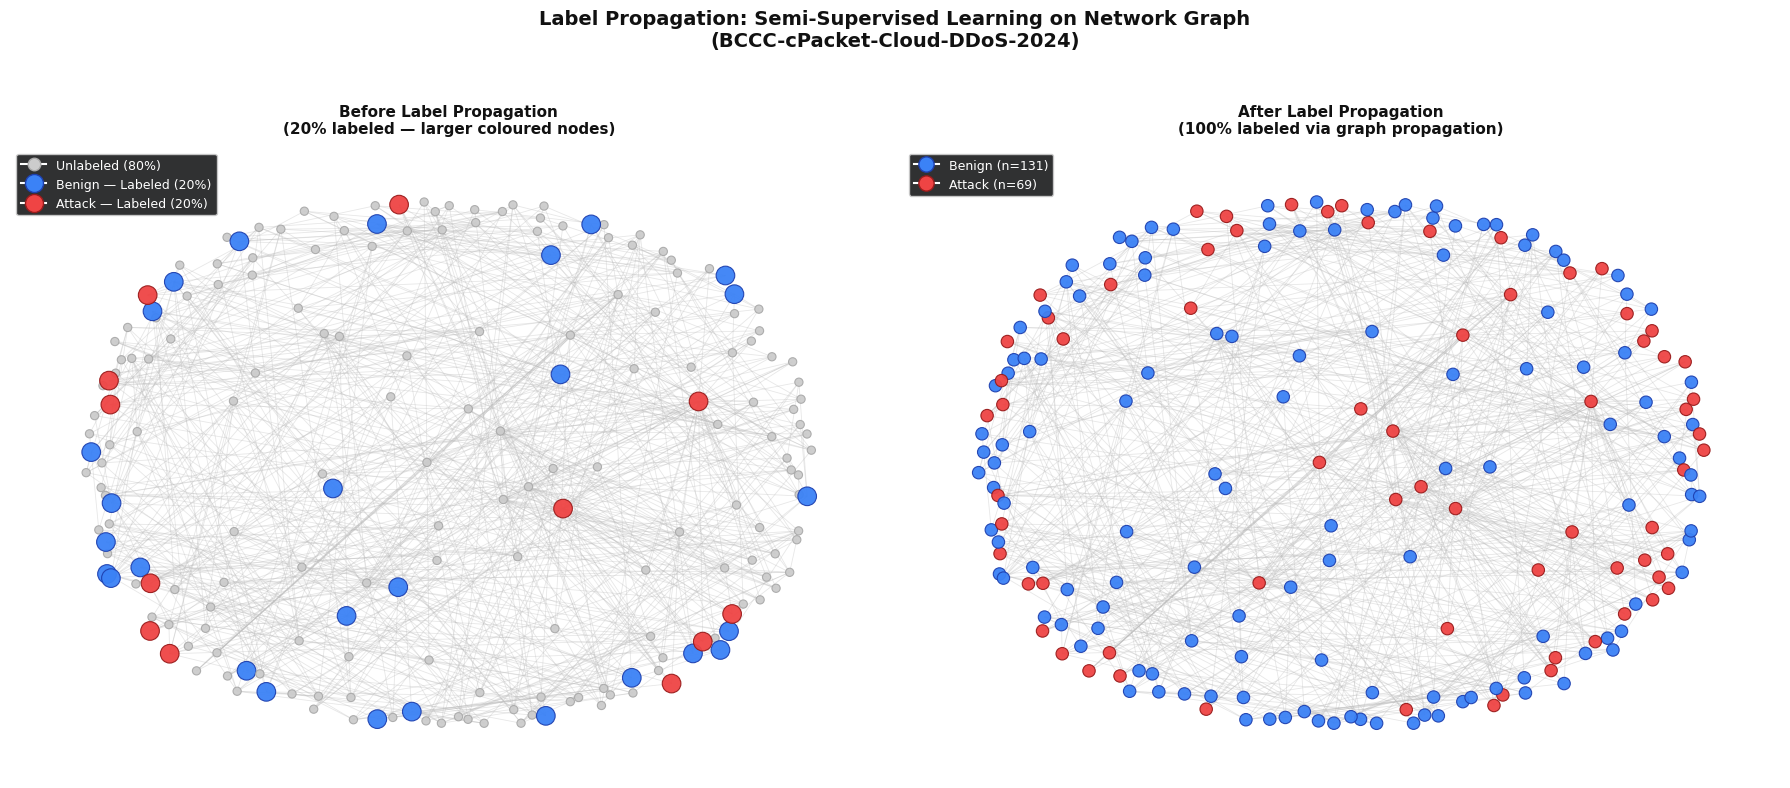

Figure saved — Before: 160 unlabeled + 40 labeled  →  After: 131 benign + 69 attack


In [15]:
# ── Plot before & after label propagation ────────────────────────────────
#
# Key fixes vs previous version:
#   1. White background (facecolor='white')
#   2. Separate spring layouts per panel so positions reflect each state clearly
#   3. "Before" panel: unlabeled nodes grey, labeled nodes larger + coloured
#      with a clear boundary (edgecolors) so they stand out
#   4. "After" panel: ALL nodes coloured by propagated label, sized uniformly,
#      with a subtle border to distinguish touching nodes
#   5. Stronger edge visibility (alpha 0.15 → 0.35) on white background
#   6. Larger node sizes overall so clusters read clearly

# Get propagated labels for the viz sample
# lp_model may be LabelPropagation or LabelSpreading depending on dataset size
try:
    lp_viz_labels = lp_model.predict(X_viz)
except Exception:
    # Sparse/LabelSpreading path: use transduction_ + kNN lookup
    from sklearn.neighbors import NearestNeighbors
    _nbrs = NearestNeighbors(n_neighbors=7, n_jobs=-1).fit(X_lp)
    _nn_idx = _nbrs.kneighbors(X_viz, return_distance=False)
    _prop   = lp_model.transduction_
    lp_viz_labels = np.array([
        np.bincount(_prop[row].astype(int), minlength=2).argmax()
        for row in _nn_idx
    ])

# ── Colour / size arrays for BEFORE panel ────────────────────────────────
node_colors_before = []
node_sizes_before  = []
node_edge_before   = []
for idx in range(VIZ_SIZE):
    if not labeled_mask_viz[idx]:
        node_colors_before.append('#CCCCCC')   # unlabeled: light grey
        node_sizes_before.append(35)
        node_edge_before.append('#AAAAAA')
    elif y_viz[idx] == 0:
        node_colors_before.append('#3B82F6')   # benign: blue
        node_sizes_before.append(180)
        node_edge_before.append('#1E40AF')
    else:
        node_colors_before.append('#EF4444')   # attack: red
        node_sizes_before.append(180)
        node_edge_before.append('#991B1B')

# ── Colour arrays for AFTER panel ────────────────────────────────────────
node_colors_after = ['#3B82F6' if lp_viz_labels[idx] == 0 else '#EF4444'
                     for idx in range(VIZ_SIZE)]
node_edge_after   = ['#1E40AF' if lp_viz_labels[idx] == 0 else '#991B1B'
                     for idx in range(VIZ_SIZE)]

# Use the same layout for both so structure is comparable
pos_viz = nx.spring_layout(G_viz, seed=42, k=1.5)

# ── Figure ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8),
                                facecolor='white')
fig.suptitle(
    'Label Propagation: Semi-Supervised Learning on Network Graph\n'
    '(BCCC-cPacket-Cloud-DDoS-2024)',
    fontsize=14, fontweight='bold', color='#111111'
)

# ── BEFORE ────────────────────────────────────────────────────────────────
ax1.set_facecolor('white')
ax1.set_title('Before Label Propagation\n(20% labeled — larger coloured nodes)',
              fontsize=11, fontweight='bold', color='#111111', pad=10)
nx.draw_networkx_edges(G_viz, pos_viz, ax=ax1,
                       alpha=0.35, width=0.6, edge_color='#BBBBBB')
nx.draw_networkx_nodes(G_viz, pos_viz, ax=ax1,
                       node_size=node_sizes_before,
                       node_color=node_colors_before,
                       edgecolors=node_edge_before,
                       linewidths=0.8, alpha=0.95)
from matplotlib.lines import Line2D
legend_before = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#CCCCCC',
           markeredgecolor='#AAAAAA', markersize=9,  label='Unlabeled (80%)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3B82F6',
           markeredgecolor='#1E40AF', markersize=13, label='Benign — Labeled (20%)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#EF4444',
           markeredgecolor='#991B1B', markersize=13, label='Attack — Labeled (20%)'),
]
ax1.legend(handles=legend_before, loc='upper left', fontsize=9,
           framealpha=0.9, edgecolor='#CCCCCC')
ax1.axis('off')

# ── AFTER ─────────────────────────────────────────────────────────────────
ax2.set_facecolor('white')
ax2.set_title('After Label Propagation\n(100% labeled via graph propagation)',
              fontsize=11, fontweight='bold', color='#111111', pad=10)
nx.draw_networkx_edges(G_viz, pos_viz, ax=ax2,
                       alpha=0.35, width=0.6, edge_color='#BBBBBB')
nx.draw_networkx_nodes(G_viz, pos_viz, ax=ax2,
                       node_size=80,
                       node_color=node_colors_after,
                       edgecolors=node_edge_after,
                       linewidths=0.8, alpha=0.95)

n_benign_prop = sum(1 for l in lp_viz_labels if l == 0)
n_attack_prop = sum(1 for l in lp_viz_labels if l == 1)
legend_after = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3B82F6',
           markeredgecolor='#1E40AF', markersize=11,
           label=f'Benign (n={n_benign_prop})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#EF4444',
           markeredgecolor='#991B1B', markersize=11,
           label=f'Attack (n={n_attack_prop})'),
]
ax2.legend(handles=legend_after, loc='upper left', fontsize=9,
           framealpha=0.9, edgecolor='#CCCCCC')
ax2.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('label_propagation_before_after.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Figure saved — Before: {VIZ_SIZE - labeled_mask_viz.sum()} unlabeled + ' +
      f'{labeled_mask_viz.sum()} labeled  →  After: {n_benign_prop} benign + {n_attack_prop} attack')


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.tree import DecisionTreeClassifier
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              precision_recall_curve, roc_curve, auc)
from sklearn.metrics import precision_recall_curve

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GATConv

import networkx as nx

print('=' * 70)
print('GNN (PyTorch GAT) — BCCC-cPacket-Cloud-DDoS-2024')
print('=' * 70)
print('\nData Preparation')
print('-' * 70)

# MAX_TRAIN / MAX_VAL caps:
#   Set to None to use ALL data (needs ~16+ GB RAM for very large files).
#   Set to an integer on laptops / Colab free tier, e.g. 500_000 / 80_000.
MAX_TRAIN = 500_000
MAX_VAL   = 80_000

# ── Reuse already-computed filtered matrix — no re-scaling needed ─────────
# X_scaled was computed in Section 3.
# X_train_f / X_test_f are the variance+correlation filtered versions from Section 5.
# We reconstruct the full filtered matrix by stacking train+test back together,
# then re-split with the same random_state so indices are consistent.
# This avoids re-running StandardScaler on the full dataset (slow + redundant).

print('Reconstructing full filtered feature matrix from existing splits...')
X_all_f_full = np.vstack([X_train_f, X_test_f])   # rejoin train+test
y_all        = np.concatenate([np.array(y_train), np.array(y_test)])
print(f'Full matrix shape: {X_all_f_full.shape}')

X_tv, X_test_g, y_tv, y_test_g = train_test_split(
    X_all_f_full, y_all,
    test_size=0.2, random_state=42, stratify=y_all
)
X_train_g, X_val_g, y_train_g, y_val_g = train_test_split(
    X_tv, y_tv,
    test_size=0.15, random_state=42, stratify=y_tv
)

if MAX_TRAIN is not None and len(X_train_g) > MAX_TRAIN:
    idx, _ = train_test_split(np.arange(len(X_train_g)),
                               train_size=MAX_TRAIN,
                               stratify=y_train_g, random_state=42)
    X_train_g, y_train_g = X_train_g[idx], y_train_g[idx]
    print(f'[INFO] GNN training capped at {MAX_TRAIN:,} rows')

if MAX_VAL is not None and len(X_val_g) > MAX_VAL:
    idx, _ = train_test_split(np.arange(len(X_val_g)),
                               train_size=MAX_VAL,
                               stratify=y_val_g, random_state=42)
    X_val_g, y_val_g = X_val_g[idx], y_val_g[idx]
    print(f'[INFO] GNN validation capped at {MAX_VAL:,} rows')

assert (y_train_g == 1).sum() > 0, 'No attack samples in GNN training set!'

print(f'Training:   {len(X_train_g):,} samples  ({y_train_g.mean()*100:.2f}% attack)')
print(f'Validation: {len(X_val_g):,} samples')
print(f'Test:       {len(X_test_g):,} samples')
print(f'Feature dimension: {X_train_g.shape[1]}')
print(f'\nUsing {len(X_train_g)/len(X_tv)*100:.1f}% of available training data')


GNN (PyTorch GAT) — BCCC-cPacket-Cloud-DDoS-2024

Data Preparation
----------------------------------------------------------------------
Reconstructing full filtered feature matrix from existing splits...
Full matrix shape: (540494, 206)
Training:   367,535 samples  (35.40% attack)
Validation: 64,860 samples
Test:       108,099 samples
Feature dimension: 206

Using 85.0% of available training data


In [17]:
print('\nBuilding Graph Structures')
print('-' * 70)

K_NEIGHBORS = 20

def build_graph(X, k=K_NEIGHBORS):
    """Build k-NN similarity graph. Returns (node features tensor, edge_index tensor)."""
    print(f'  Building k-NN graph (k={k}, {len(X):,} nodes)...')
    start = time.time()
    nbrs  = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree', n_jobs=-1)
    nbrs.fit(X)
    _, indices  = nbrs.kneighbors(X)
    rows        = np.repeat(np.arange(len(X)), k)
    cols        = indices[:, 1:].flatten()
    edge_index  = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
    x_t         = torch.tensor(X, dtype=torch.float32)
    elapsed     = time.time() - start
    print(f'  Done in {elapsed:.1f}s — {len(X):,} nodes, {edge_index.shape[1]:,} edges')
    return x_t, edge_index

X_tr_t, ei_tr = build_graph(X_train_g)
X_va_t, ei_va = build_graph(X_val_g)
X_te_t, ei_te = build_graph(X_test_g)

y_tr_t = torch.tensor(y_train_g, dtype=torch.long)
y_va_t = torch.tensor(y_val_g,   dtype=torch.long)
y_te_t = torch.tensor(y_test_g,  dtype=torch.long)


Building Graph Structures
----------------------------------------------------------------------
  Building k-NN graph (k=20, 367,535 nodes)...
  Done in 6716.9s — 367,535 nodes, 7,350,700 edges
  Building k-NN graph (k=20, 64,860 nodes)...
  Done in 168.4s — 64,860 nodes, 1,297,200 edges
  Building k-NN graph (k=20, 108,099 nodes)...
  Done in 521.4s — 108,099 nodes, 2,161,980 edges


In [18]:
def get_batches(n, batch_size, shuffle=False):
    idx = np.random.permutation(n) if shuffle else np.arange(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def subgraph(node_idx, x, edge_index, y):
    """Extract induced subgraph for node_idx; remap node ids to 0-based."""
    node_set  = torch.tensor(node_idx, dtype=torch.long)
    node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
    node_mask[node_set] = True
    edge_mask = node_mask[edge_index[0]] & node_mask[edge_index[1]]
    sub_edges = edge_index[:, edge_mask]
    mapping   = torch.full((x.shape[0],), -1, dtype=torch.long)
    mapping[node_set] = torch.arange(len(node_set))
    sub_edges = mapping[sub_edges]
    return x[node_set], sub_edges, y[node_set]

# ── GAT Model ────────────────────────────────────────────────────────────
class GATClassifier(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, out_ch=2):
        super().__init__()
        self.conv1 = GATConv(in_ch,      hidden, heads=4, dropout=0.3, concat=True)
        self.conv2 = GATConv(hidden * 4, hidden, heads=2, dropout=0.3, concat=True)
        self.conv3 = GATConv(hidden * 2, hidden, heads=1, dropout=0.3, concat=False)
        self.lin   = Linear(hidden, out_ch)
        self.bn1   = torch.nn.BatchNorm1d(hidden * 4)
        self.bn2   = torch.nn.BatchNorm1d(hidden * 2)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.conv3(x, edge_index))
        return self.lin(x)

n_benign     = int((y_tr_t == 0).sum())
n_attack     = int((y_tr_t == 1).sum())
class_weight = torch.tensor([1.0, n_benign / max(n_attack, 1)], dtype=torch.float32)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_ch     = X_tr_t.shape[1]   # 300+ features from NTLFlowLyzer
model     = GATClassifier(in_ch=in_ch).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.8)
criterion = torch.nn.CrossEntropyLoss(weight=class_weight.to(device))

print(f'\nDevice: {device}')
print(f'Input features: {in_ch}')
print(f'Class weights — Benign: 1.00 | Attack: {n_benign / max(n_attack, 1):.2f}')
print(model)


Device: cpu
Input features: 206
Class weights — Benign: 1.00 | Attack: 1.83
GATClassifier(
  (conv1): GATConv(206, 64, heads=4)
  (conv2): GATConv(256, 64, heads=2)
  (conv3): GATConv(128, 64, heads=1)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [19]:
BATCH_SIZE = 2000
PATIENCE   = 15

print('\nTraining GNN — up to 100 epochs (early stopping patience=15)')
print(f"{'Epoch':>6} | {'Loss':>8} | {'Val F1':>8} | {'Recall':>8} | {'Precision':>10}")
print('-' * 55)

def run_epoch(x, edge_index, y, n):
    model.train()
    total_loss = 0
    for b_idx in get_batches(n, BATCH_SIZE, shuffle=True):
        xb, eib, yb = subgraph(b_idx, x, edge_index, y)
        xb, eib, yb = xb.to(device), eib.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb, eib)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(get_batches(n, BATCH_SIZE)), 1)

def get_probs(x, edge_index, y, n):
    model.eval()
    all_probs, all_true = [], []
    with torch.no_grad():
        for b_idx in get_batches(n, BATCH_SIZE, shuffle=False):
            xb, eib, yb = subgraph(b_idx, x, edge_index, y)
            xb, eib = xb.to(device), eib.to(device)
            out  = model(xb, eib)
            prob = F.softmax(out, dim=1)[:, 1]
            all_probs.append(prob.cpu())
            all_true.append(yb)
    return torch.cat(all_probs).numpy(), torch.cat(all_true).numpy()

best_f1, patience_ctr, best_state, best_thresh = 0.0, 0, None, 0.5
start_gnn = time.time()

for epoch in range(1, 101):
    loss = run_epoch(X_tr_t, ei_tr, y_tr_t, len(X_train_g))
    scheduler.step()

    if epoch % 5 == 0:
        val_probs, val_true = get_probs(X_va_t, ei_va, y_va_t, len(X_val_g))

        pr_v, rc_v, th_v = precision_recall_curve(val_true, val_probs)
        f1_v = 2 * pr_v * rc_v / (pr_v + rc_v + 1e-10)
        bi   = np.argmax(f1_v)
        tv   = th_v[bi] if bi < len(th_v) else 0.5
        vpred = (val_probs >= tv).astype(int)

        vf1  = f1_score(val_true, vpred, zero_division=0)
        vrec = recall_score(val_true, vpred, zero_division=0)
        vpr  = precision_score(val_true, vpred, zero_division=0)

        print(f'{epoch:>6} | {loss:>8.4f} | {vf1:>8.4f} | {vrec:>7.1%} | {vpr:>9.1%}')

        if vf1 > best_f1:
            best_f1, patience_ctr, best_thresh = vf1, 0, tv
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

elapsed_gnn = time.time() - start_gnn
if best_state:
    model.load_state_dict(best_state)
    print(f'\nRestored best model (Val F1: {best_f1:.4f})')
print(f'Training time: {elapsed_gnn:.1f}s ({elapsed_gnn / 60:.1f} min)')


Training GNN — up to 100 epochs (early stopping patience=15)
 Epoch |     Loss |   Val F1 |   Recall |  Precision
-------------------------------------------------------
     5 |   0.4120 |   0.8934 |   83.2% |     96.5%
    10 |   0.4103 |   0.8967 |   82.7% |     97.9%
    15 |   0.4103 |   0.8978 |   83.6% |     97.0%
    20 |   0.4112 |   0.8975 |   82.8% |     98.0%
    25 |   0.4092 |   0.8959 |   83.0% |     97.3%
    30 |   0.4085 |   0.8974 |   83.1% |     97.5%
    35 |   0.4100 |   0.8979 |   83.1% |     97.7%
    40 |   0.4090 |   0.8973 |   83.0% |     97.6%
    45 |   0.4087 |   0.8972 |   83.0% |     97.6%
    50 |   0.4073 |   0.8972 |   83.1% |     97.5%
    55 |   0.4087 |   0.8975 |   83.1% |     97.5%
    60 |   0.4071 |   0.8973 |   83.5% |     96.9%
    65 |   0.4065 |   0.8975 |   83.1% |     97.6%
    70 |   0.4063 |   0.8977 |   83.1% |     97.6%
    75 |   0.4065 |   0.8884 |   81.3% |     97.9%
    80 |   0.4060 |   0.8882 |   81.3% |     97.9%
    85 |   0.

In [20]:
print('\nEvaluation on Test Set')
print('-' * 70)

test_probs, test_true = get_probs(X_te_t, ei_te, y_te_t, len(X_test_g))
test_pred = (test_probs >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(test_true, test_pred).ravel()
acc  = (tp + tn) / (tp + tn + fp + fn) * 100
far  = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
und  = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0
rec  = tp / (tp + fn)       if (tp + fn) > 0 else 0
prec = tp / (tp + fp)       if (tp + fp) > 0 else 0
f1   = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0

print('\n' + '=' * 70)
print('GNN RESULTS')
print('=' * 70)
print(f'  TN: {tn:,}  |  FP: {fp:,}')
print(f'  FN: {fn:,}  |  TP: {tp:,}')
print(f'\n  ACC:       {acc:.4f}%')
print(f'  FAR:       {far:.4f}%')
print(f'  UND:       {und:.4f}%')
print(f'  Recall:    {rec:.2%}')
print(f'  Precision: {prec:.2%}')
print(f'  F1 Score:  {f1:.4f}')
print(f'\n  Training samples:   {len(X_train_g):,}')
print(f'  Validation samples: {len(X_val_g):,}')
print(f'  Test samples:       {len(X_test_g):,}')
print(f'  Graph:              {len(X_test_g):,} nodes, {ei_te.shape[1]:,} edges')
print(f'  Threshold:          {best_thresh:.4f}')
print(f'  Training time:      {elapsed_gnn:.1f}s')
print('=' * 70)

gnn_result = {
    'Model': 'GNN (PyTorch GAT)',
    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    'ACC': round(acc, 4),
    'FAR': round(far, 4),
    'UND': round(und, 4),
    'Time': round(elapsed_gnn, 1)
}


Evaluation on Test Set
----------------------------------------------------------------------

GNN RESULTS
  TN: 69,046  |  FP: 790
  FN: 6,570  |  TP: 31,693

  ACC:       93.1914%
  FAR:       1.1312%
  UND:       17.1706%
  Recall:    82.83%
  Precision: 97.57%
  F1 Score:  0.8960

  Training samples:   367,535
  Validation samples: 64,860
  Test samples:       108,099
  Graph:              108,099 nodes, 2,161,980 edges
  Threshold:          0.4977
  Training time:      1231.4s


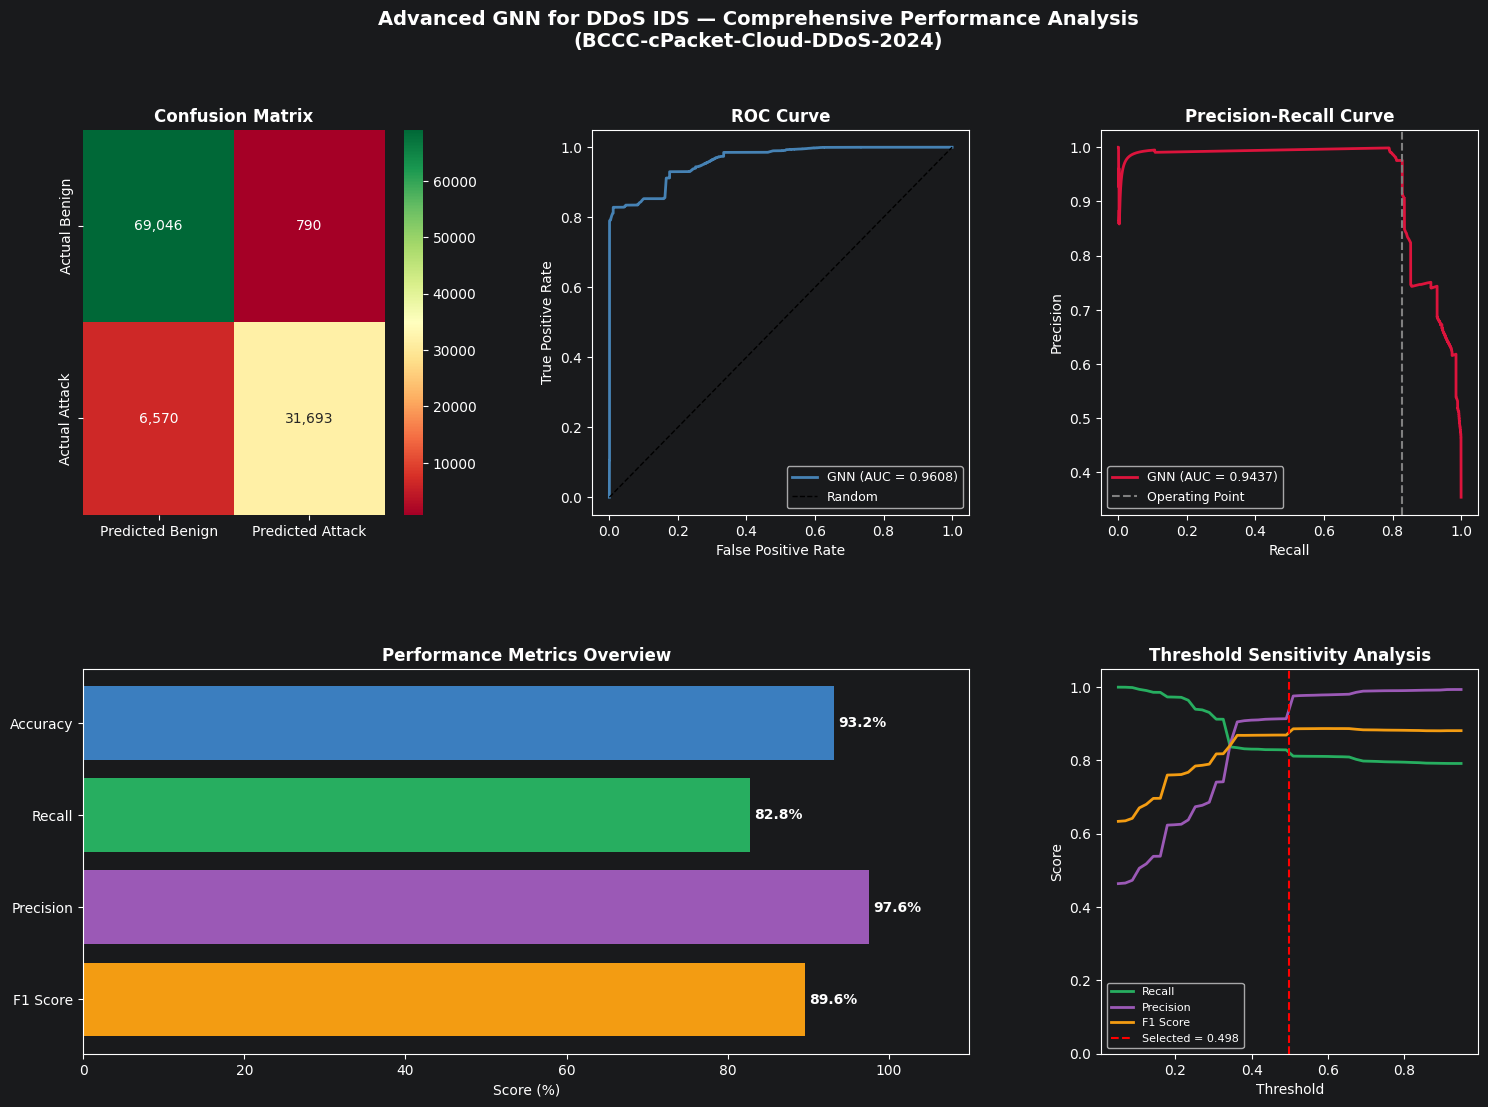

Figure saved: gnn_performance_analysis.png


In [21]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Advanced GNN for DDoS IDS — Comprehensive Performance Analysis\n(BCCC-cPacket-Cloud-DDoS-2024)',
             fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_cm = fig.add_subplot(gs[0, 0])
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt=',', cmap='RdYlGn',
            xticklabels=['Predicted Benign', 'Predicted Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'],
            ax=ax_cm, cbar=True)
ax_cm.set_title('Confusion Matrix', fontweight='bold')

ax_roc = fig.add_subplot(gs[0, 1])
fpr_r, tpr_r, _ = roc_curve(test_true, test_probs)
roc_auc = auc(fpr_r, tpr_r)
ax_roc.plot(fpr_r, tpr_r, color='steelblue', lw=2,
            label=f'GNN (AUC = {roc_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve', fontweight='bold')
ax_roc.legend(fontsize=9)

ax_pr = fig.add_subplot(gs[0, 2])
pr_vals, rc_vals, _ = precision_recall_curve(test_true, test_probs)
pr_auc = auc(rc_vals, pr_vals)
ax_pr.plot(rc_vals, pr_vals, color='crimson', lw=2,
           label=f'GNN (AUC = {pr_auc:.4f})')
ax_pr.axvline(x=rec, color='gray', linestyle='--', lw=1.5, label='Operating Point')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve', fontweight='bold')
ax_pr.legend(fontsize=9)

ax_met = fig.add_subplot(gs[1, 0:2])
metric_names  = ['F1 Score', 'Precision', 'Recall', 'Accuracy']
metric_values = [f1 * 100, prec * 100, rec * 100, acc]
bar_colors    = ['#F39C12', '#9B59B6', '#27AE60', '#3B7EBF']
bars_met = ax_met.barh(metric_names, metric_values, color=bar_colors)
for bar, val in zip(bars_met, metric_values):
    ax_met.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontweight='bold')
ax_met.set_xlim(0, 110)
ax_met.set_xlabel('Score (%)')
ax_met.set_title('Performance Metrics Overview', fontweight='bold')

ax_thr = fig.add_subplot(gs[1, 2])
thresholds_plot = np.linspace(0.05, 0.95, 50)
recalls_plot, precisions_plot, f1s_plot = [], [], []
for t in thresholds_plot:
    pred_t = (test_probs >= t).astype(int)
    recalls_plot.append(recall_score(test_true, pred_t, zero_division=0))
    precisions_plot.append(precision_score(test_true, pred_t, zero_division=0))
    f1s_plot.append(f1_score(test_true, pred_t, zero_division=0))

ax_thr.plot(thresholds_plot, recalls_plot,    color='#27AE60', lw=2, label='Recall')
ax_thr.plot(thresholds_plot, precisions_plot, color='#9B59B6', lw=2, label='Precision')
ax_thr.plot(thresholds_plot, f1s_plot,        color='#F39C12', lw=2, label='F1 Score')
ax_thr.axvline(x=best_thresh, color='red', linestyle='--', lw=1.5,
               label=f'Selected = {best_thresh:.3f}')
ax_thr.set_xlabel('Threshold')
ax_thr.set_ylabel('Score')
ax_thr.set_title('Threshold Sensitivity Analysis', fontweight='bold')
ax_thr.legend(fontsize=8)
ax_thr.set_ylim(0, 1.05)

plt.savefig('gnn_performance_analysis.png', dpi=150)
plt.show()
print('Figure saved: gnn_performance_analysis.png')

In [22]:
all_results = pd.DataFrame(results + [lp_result, gnn_result])

print('FULL COMPARISON TABLE — BCCC-cPacket-Cloud-DDoS-2024')
print('=' * 70)
print(all_results[['Model', 'ACC', 'FAR', 'UND', 'Time']].to_string(index=False))

best_acc = all_results.loc[all_results['ACC'].idxmax(), 'Model']
best_far = all_results.loc[all_results['FAR'].idxmin(), 'Model']
best_und = all_results.loc[all_results['UND'].idxmin(), 'Model']

print(f'\nBest Accuracy:         {best_acc}')
print(f'Lowest FAR:            {best_far}')
print(f'Lowest UND (critical): {best_und}')

FULL COMPARISON TABLE — BCCC-cPacket-Cloud-DDoS-2024
              Model     ACC     FAR     UND    Time
Logistic Regression 90.4476  4.6724 18.4591    6.32
      Random Forest 96.6105  2.8281  4.4142   24.72
        Naive Bayes 41.3047 90.3417  0.9356    2.03
                KNN 96.3737  2.5374  5.6138 2735.65
      Decision Tree 96.3885  3.8834  3.1153   19.24
  Label Propagation 96.3857  1.7226  7.0669  602.67
  GNN (PyTorch GAT) 93.1914  1.1312 17.1706 1231.40

Best Accuracy:         Random Forest
Lowest FAR:            GNN (PyTorch GAT)
Lowest UND (critical): Naive Bayes


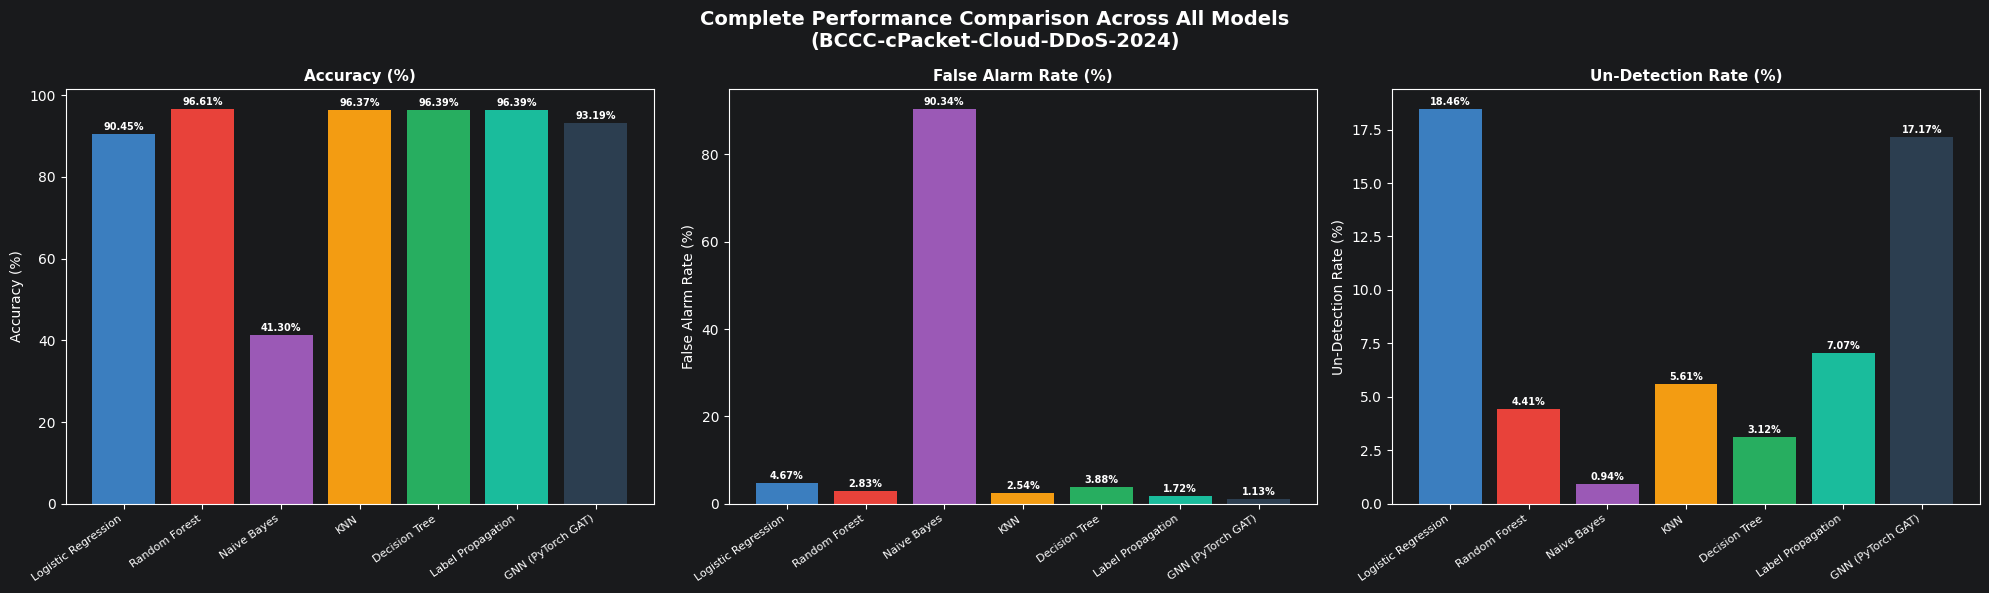

Figure saved: complete_comparison_all_models.png


In [23]:
all_colors = colors + ['#1ABC9C', '#2C3E50']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Complete Performance Comparison Across All Models\n(BCCC-cPacket-Cloud-DDoS-2024)',
             fontsize=14, fontweight='bold')

metrics = ['ACC', 'FAR', 'UND']
titles  = ['Accuracy (%)', 'False Alarm Rate (%)', 'Un-Detection Rate (%)']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(all_results['Model'], all_results[metric],
                  color=all_colors[:len(all_results)])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_xticks(range(len(all_results)))
    ax.set_xticklabels(all_results['Model'], rotation=35, ha='right', fontsize=8)
    for bar, val in zip(bars, all_results[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(all_results[metric]) * 0.01,
                f'{val:.2f}%', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('complete_comparison_all_models.png', dpi=150)
plt.show()
print('Figure saved: complete_comparison_all_models.png')